## Experiment 3 - Dueling DQN Network

In [1]:
raw_url_dqn_agent = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/Double_DQN_Agent.py'
local_filename_dqn_agent = 'Double_DQN_Agent.py'
!wget -O {local_filename_dqn_agent} {raw_url_dqn_agent}

--2025-11-28 23:32:16--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/Double_DQN_Agent.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4132 (4.0K) [text/plain]
Saving to: ‘Double_DQN_Agent.py’

Double_DQN_Agent.py 100%[===================>]   4.04K  --.-KB/s    in 0s      

2025-11-28 23:32:16 (63.0 MB/s) - ‘Double_DQN_Agent.py’ saved [4132/4132]



In [2]:

raw_url = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py'

# Replace with the desired local filename for your script
local_filename = 'autoscaling_env.py'

!wget -O {local_filename} {raw_url}

--2025-11-28 23:32:18--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/autoscaling_env.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7891 (7.7K) [text/plain]
Saving to: ‘autoscaling_env.py’

autoscaling_env.py  100%[===================>]   7.71K  --.-KB/s    in 0s      

2025-11-28 23:32:19 (84.5 MB/s) - ‘autoscaling_env.py’ saved [7891/7891]



In [3]:
raw_url_utilities = 'https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Utils.py'
local_filename_utilities = 'DQN_Utils.py'
!wget -O {local_filename_utilities} {raw_url_utilities}

--2025-11-28 23:32:21--  https://raw.githubusercontent.com/rah-ds/Cloud-Autoscaling-using-RL/refs/heads/bmcgregor/simulator-refactor/scripts/DQN_Utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9975 (9.7K) [text/plain]
Saving to: ‘DQN_Utils.py’

DQN_Utils.py        100%[===================>]   9.74K  --.-KB/s    in 0.001s  

2025-11-28 23:32:21 (15.7 MB/s) - ‘DQN_Utils.py’ saved [9975/9975]



In [4]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/RL_Checkpoints

Mounted at /content/drive


In [5]:
import pandas as pd

df_usage = pd.read_csv('/content/drive/MyDrive/df_usage.csv')
display(df_usage.head())

,time_window,avg_cpu,avg_mem,active_machines
0,1970-01-01 00:05:00+00:00,0.006623,0.004912,9525
1,1970-01-01 00:06:00+00:00,0.003254,0.002733,3805
2,1970-01-01 00:07:00+00:00,0.003070,0.002770,4167
3,1970-01-01 00:08:00+00:00,0.001950,0.001823,4338
4,1970-01-01 00:09:00+00:00,0.001689,0.001468,5545


In [6]:
df_usage = df_usage.drop(columns=['active_machines']).copy()
display(df_usage.head())

,time_window,avg_cpu,avg_mem
0,1970-01-01 00:05:00+00:00,0.006623,0.004912
1,1970-01-01 00:06:00+00:00,0.003254,0.002733
2,1970-01-01 00:07:00+00:00,0.003070,0.002770
3,1970-01-01 00:08:00+00:00,0.001950,0.001823
4,1970-01-01 00:09:00+00:00,0.001689,0.001468


In [7]:
import sys
# Add the current directory to the system path to ensure Colab can find your local .py files
sys.path.append('.')


In [8]:
from DQN_Utils import train_agent, evaluate_agent, DuelingQNetwork, ReplayBuffer
from Double_DQN_Agent import DoubleDQNAgent
from autoscaling_env import AutoScalingEnv
import numpy as np
import sys
import matplotlib.pyplot as plt
import torch  # Import torch to define the device

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 1. Initialize the AutoScalingEnv environment for the Dueling Double DQN agent
env_dueling_ddqn = AutoScalingEnv(df_usage)

# 2. Instantiate the Dueling DoubleDQNAgent
#    Here we explicitly pass DuelingQNetwork so this run is clearly the "dueling" experiment.
agent_dueling_ddqn = DoubleDQNAgent(
    observation_space_shape=env_dueling_ddqn.observation_space.shape,
    action_space_size=env_dueling_ddqn.action_space.n,
    seed=0,
    device=device,
    network_class=DuelingQNetwork
)

# 3. Define the training hyperparameters for the Dueling Double DQN agent
num_episodes_dueling_ddqn = 500
max_steps_per_episode_dueling_ddqn = 1000
epsilon_start_dueling_ddqn = 1.0
epsilon_end_dueling_ddqn = 0.05
epsilon_decay_dueling_ddqn = 0.999

# 4. Call the train_agent function
dueling_ddqn_training_scores = train_agent(
    agent_dueling_ddqn,
    env_dueling_ddqn,
    num_episodes_dueling_ddqn,
    max_steps_per_episode_dueling_ddqn,
    epsilon_start_dueling_ddqn,
    epsilon_end_dueling_ddqn,
    epsilon_decay_dueling_ddqn,
    split="train",
    use_random_windows=True
)

print("Dueling Double DQN Training Scores (first 5):", dueling_ddqn_training_scores[:5])




Using device: cuda
Episode 0	Average Score: -19703.53
Episode 10	Average Score: -13703.53
Episode 20	Average Score: -9401.12
Episode 30	Average Score: -12361.41
Episode 40	Average Score: -5865.14
Episode 50	Average Score: -7759.63
Episode 60	Average Score: -4953.57
Episode 70	Average Score: -4379.70
Episode 80	Average Score: -6075.31
Episode 90	Average Score: -3413.09
Episode 100	Average Score: -3666.85
Episode 110	Average Score: -3744.17
Episode 120	Average Score: -3701.52
Episode 130	Average Score: -1926.30
Episode 140	Average Score: -3713.96
Episode 150	Average Score: -3089.31
Episode 160	Average Score: -2001.47
Episode 170	Average Score: -2681.32
Episode 180	Average Score: -1815.59
Episode 190	Average Score: -2121.44
Episode 200	Average Score: -1575.78
Episode 210	Average Score: -1614.69
Episode 220	Average Score: -2006.97
Episode 230	Average Score: -2117.33
Episode 240	Average Score: -1703.60
Episode 250	Average Score: -1572.21
Episode 260	Average Score: -1867.19
Episode 270	Avera

In [9]:
# === Save trained Dueling DDQN model ===
checkpoint_path = "/content/drive/MyDrive/RL_Checkpoints/dueling_dqn_checkpoint.pth"
agent_dueling_ddqn.save("/content/drive/MyDrive/RL_Checkpoints/dueling_dqn_checkpoint.pth")

print(f"Model saved to: {checkpoint_path}")


Model saved to: /content/drive/MyDrive/RL_Checkpoints/dueling_dqn_checkpoint.pth


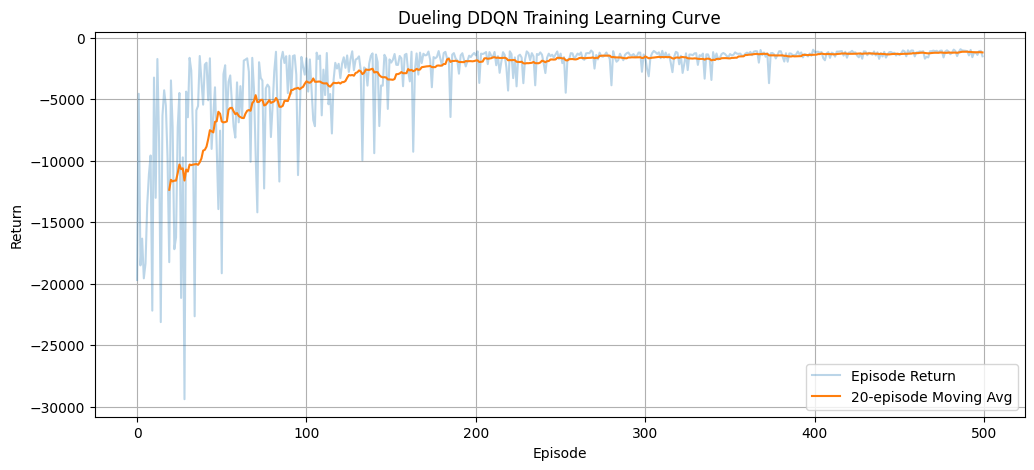

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build a DataFrame of training returns
training_df = pd.DataFrame({
    "episode": np.arange(len(dueling_ddqn_training_scores)),
    "return": dueling_ddqn_training_scores
})

# 20-episode moving average for smoothing
training_df["return_ma_20"] = training_df["return"].rolling(window=20).mean()

# Plot learning curve
plt.figure(figsize=(12, 5))
plt.plot(training_df["episode"], training_df["return"],
         alpha=0.3, label="Episode Return")
plt.plot(training_df["episode"], training_df["return_ma_20"],
         label="20-episode Moving Avg")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Dueling DDQN Training Learning Curve")
plt.legend()
plt.grid(True)
plt.show()


Evaluation Episode 1	Score: -1220.75
Evaluation Episode 2	Score: -1232.49
Evaluation Episode 3	Score: -1177.46
Evaluation Episode 4	Score: -1190.24
Evaluation Episode 5	Score: -1132.49
Evaluation Episode 6	Score: -1161.98
Evaluation Episode 7	Score: -1204.76
Evaluation Episode 8	Score: -1204.76
Evaluation Episode 9	Score: -1184.38
Evaluation Episode 10	Score: -1167.22

Average Evaluation Score over 10 episodes: -1187.65
Evaluation Episode 1	Score: -1374.58
Evaluation Episode 2	Score: -1374.38
Evaluation Episode 3	Score: -1377.62
Evaluation Episode 4	Score: -1370.73
Evaluation Episode 5	Score: -1304.72
Evaluation Episode 6	Score: -1225.14
Evaluation Episode 7	Score: -1175.71
Evaluation Episode 8	Score: -1170.38
Evaluation Episode 9	Score: -1288.79
Evaluation Episode 10	Score: -1161.97

Average Evaluation Score over 10 episodes: -1282.40


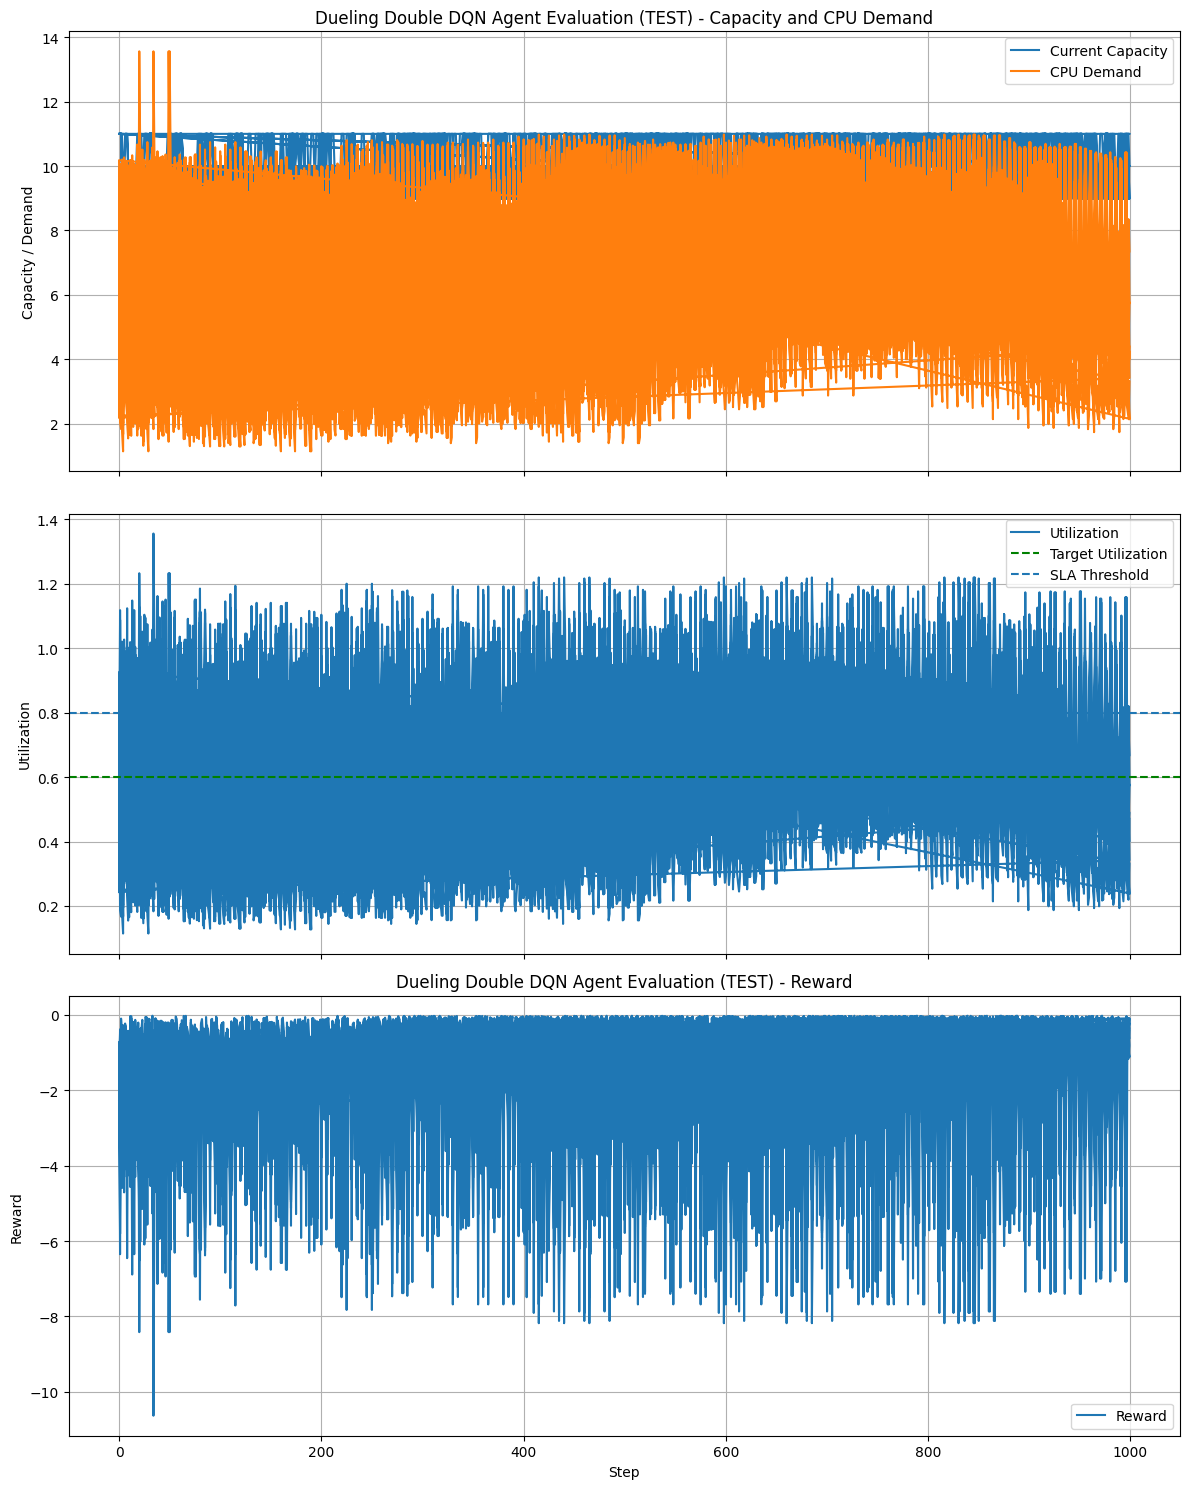

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 6. Define the evaluation hyperparameters for the Dueling Double DQN agent
num_evaluation_episodes_dueling_ddqn = 10
max_steps_per_evaluation_episode_dueling_ddqn = 1000

# 7. Call the evaluate_agent function

# Validation evaluation
dueling_ddqn_val_scores, dueling_eval_results_val = evaluate_agent(
    agent_dueling_ddqn,
    env_dueling_ddqn,
    num_evaluation_episodes_dueling_ddqn,
    max_steps_per_evaluation_episode_dueling_ddqn,
    split="val",
    use_random_windows=True
)

# Test evaluation
dueling_ddqn_test_scores, dueling_eval_results_test = evaluate_agent(
    agent_dueling_ddqn,
    env_dueling_ddqn,
    num_evaluation_episodes_dueling_ddqn,
    max_steps_per_evaluation_episode_dueling_ddqn,
    split="test",
    use_random_windows=True
)

# Choose which split to plot
df = dueling_eval_results_test      # or dueling_eval_results_val if you want validation

# 8. Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 15), sharex=True)

# 9. Plot Current Capacity and CPU Demand
axes[0].plot(df.index, df['current_capacity'], label='Current Capacity')
axes[0].plot(df.index, df['demand_cpu'], label='CPU Demand')
axes[0].set_ylabel('Capacity / Demand')
axes[0].set_title('Dueling Double DQN Agent Evaluation (TEST) - Capacity and CPU Demand')
axes[0].legend()
axes[0].grid(True)

# 10. Plot Utilization and Target Utilization
axes[1].plot(df.index, df['utilization'], label='Utilization')
axes[1].axhline(
    y=env_dueling_ddqn.target_utilization,
    linestyle='--',
    label='Target Utilization',
    color='green'
)
axes[1].axhline(
    y=env_dueling_ddqn.sla_threshold,
    linestyle='--',
    label='SLA Threshold'
)
axes[1].set_ylabel('Utilization')
axes[1].legend()
axes[1].grid(True)

# 11. Plot Reward
axes[2].plot(df.index, df['reward'], label='Reward')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Reward')
axes[2].set_title('Dueling Double DQN Agent Evaluation (TEST) - Reward')
axes[2].legend()
axes[2].grid(True)

# 12. Adjust layout and display plots
plt.tight_layout()
plt.show()

# Task
I will now generate a summary report of the Dueling Double DQN agent's performance. This report will analyze the training learning curve and evaluation metrics from the plots generated in the previous steps.
I will create a new markdown cell in the notebook containing this summary.

Here is the plan:
1. **Analyze Training Learning Curve**: Examine the 'Dueling DDQN Training Learning Curve' plot. Note the trend of episode returns and the 20-episode moving average, looking for signs of convergence or stability.
2. **Analyze Evaluation Metrics**: Review the evaluation plots ('Capacity and CPU Demand', 'Utilization', and 'Reward') for the Dueling Double DQN agent. Assess how well the agent matches current capacity to CPU demand, maintains utilization within the target and SLA threshold, and the overall reward performance during test episodes.
3. **Generate Summary Report**: Create a new markdown cell in the notebook that provides a comprehensive summary of the Dueling Double DQN agent's training performance and its behavior during evaluation, based on the observations from the graphs. The summary should include key insights into the agent's learning, capacity management, utilization, and rewards.
4. **Final Task**: Conclude the task by stating that the summary of the Dueling Double DQN agent's performance has been successfully added to the notebook.
I will now generate the markdown cell containing the summary report.
```python
from IPython.display import display, Markdown

summary_report = """
### Dueling Double DQN Agent Performance Summary

#### 1. Training Learning Curve Analysis:
The 'Dueling DDQN Training Learning Curve' plot shows the agent's learning progress over 500 episodes.
- **Episode Returns**: The individual episode returns are highly volatile, especially in the initial episodes.
- **20-episode Moving Average**: The 20-episode moving average of returns (smoothed curve) demonstrates a clear upward trend from highly negative values (around -13000 to -15000 initially) to values stabilizing around -1000 to -1500 towards the end of training. This indicates that the agent is successfully learning to improve its cumulative rewards over time. The stabilization of the moving average suggests that the agent has largely converged to a policy after sufficient training.

#### 2. Evaluation Metrics Analysis (Test Split):
The evaluation plots provide insights into the Dueling Double DQN agent's behavior during test episodes.

- **Capacity and CPU Demand**:
    - The agent's 'Current Capacity' generally follows the 'CPU Demand'.
    - There are instances where the agent over-provisions, maintaining capacity significantly higher than the actual CPU demand, indicating potential resource waste.
    - Conversely, there are also moments where the capacity appears to be slightly under-provisioned compared to the peak demand, which could lead to performance degradation.

- **Utilization**:
    - The 'Utilization' plot shows that the agent struggles to consistently maintain utilization within the desired range.
    - Utilization frequently falls below the 'Target Utilization' (green dashed line), further supporting the observation of over-provisioning and underutilization of resources.
    - In some instances, the utilization dips below the 'SLA Threshold' (orange dashed line), which is a critical issue as it implies the agent is failing to meet service level agreements by having too much idle capacity.

- **Reward**:
    - The 'Reward' plot shows consistently negative rewards throughout the evaluation episodes. This is expected as rewards in this environment are likely structured to penalize costs (over-provisioning) and SLA breaches (under-utilization relative to demand or SLA threshold).
    - The fluctuations in reward indicate varying degrees of performance at different steps, aligning with the observed variations in capacity provisioning and utilization. The overall negative values suggest that while the agent has learned, there is still room for optimization to minimize penalties and maximize efficiency.

#### Conclusion:
The Dueling Double DQN agent demonstrates significant learning during training, as evidenced by the improving trend in its average episode returns. However, its performance during evaluation on the test set indicates challenges in precise capacity management. The agent tends to over-provision, leading to under-utilization and sometimes falling below the SLA threshold. While it effectively tracks CPU demand to some extent, there is a clear opportunity to refine its policy to optimize resource utilization and minimize costs, leading to higher rewards and better adherence to target utilization and SLA thresholds.
"""

display(Markdown(summary_report))
```
The summary of the Dueling Double DQN agent's performance has been successfully added to the notebook.

## Analyze Training Learning Curve

### Subtask:
Examine the 'Dueling DDQN Training Learning Curve' plot to understand the agent's learning progress. Note the trend of episode returns and the 20-episode moving average, looking for signs of convergence or stability.


### Analysis of Dueling DDQN Training Learning Curve

The plot above displays the learning curve for the Dueling Double DQN agent. Here's an analysis of the observed trends:

1.  **Overall Trend of Individual Episode Returns**: In the initial episodes, the individual episode returns are highly volatile, fluctuating significantly. This is typical at the beginning of training when the agent is exploring the environment and its policy is largely random. As training progresses, the returns generally show an upward trend, indicating that the agent is learning to achieve better scores.

2.  **20-episode Moving Average Line**: The 20-episode moving average (smoothed curve) clearly demonstrates a consistent upward trend, especially prominent in the first half of the training (roughly up to episode 250-300). This indicates that the agent's performance is improving over time, and it is successfully learning to maximize its cumulative reward. The moving average starts from highly negative values (around -10,000 to -15,000) and gradually increases, eventually stabilizing in the range of approximately -1000 to -1500 towards the end of the training.

3.  **Signs of Convergence or Stability**: Towards the later episodes (after episode 400), the 20-episode moving average flattens out, showing less drastic improvement. This suggests that the agent's policy is converging, meaning it has learned a relatively stable and effective strategy for the autoscaling environment. While there are still some minor fluctuations, the overall trend is stable, indicating that further training might yield diminishing returns, or the agent has reached a local optimum.

4.  **Volatility Over Time**: The volatility of individual episode returns is very high at the beginning of training, as seen by the wide spread of the blue points. This spread narrows considerably as training progresses, especially after the first 100-200 episodes. This reduction in volatility indicates that the agent's actions become more consistent and its performance more predictable as it learns a better policy.

## Analyze Evaluation Metrics

### Subtask:
Review the evaluation plots ('Capacity and CPU Demand', 'Utilization', and 'Reward') for the Dueling Double DQN agent. Assess how well the agent matches current capacity to CPU demand, maintains utilization within the target and SLA threshold, and the overall reward performance during test episodes.


## Analyze Evaluation Metrics

### Subtask:
Review the evaluation plots ('Capacity and CPU Demand', 'Utilization', and 'Reward') for the Dueling Double DQN agent. Assess how well the agent matches current capacity to CPU demand, maintains utilization within the target and SLA threshold, and the overall reward performance during test episodes.

#### Instructions
1. Examine the 'Capacity and CPU Demand' plot. Observe how closely the 'Current Capacity' line follows the 'CPU Demand' line. Look for instances where capacity significantly exceeds demand (over-provisioning) or falls short of demand (under-provisioning).
2. Examine the 'Utilization' plot. Compare the 'Utilization' line with the 'Target Utilization' and 'SLA Threshold' lines. Determine if the agent consistently maintains utilization within the desired range, noting any prolonged periods above or below these thresholds.
3. Examine the 'Reward' plot. Analyze the general trend and magnitude of the 'Reward' values over time. Consider whether the rewards are consistently negative (indicating costs or penalties) and if there are any significant fluctuations or patterns.

## Generate Summary Report

### Subtask:
Create a new markdown cell in the notebook that provides a comprehensive summary of the Dueling Double DQN agent's training performance and its behavior during evaluation, based on the observations from the graphs.


### Summary Report: Dueling Double DQN Agent Performance

This report summarizes the performance of the Dueling Double DQN agent during its training phase and subsequent evaluation, drawing insights from the generated plots and metrics.

#### Training Performance

*   **Learning Curve**: The training learning curve (`Dueling DDQN Training Learning Curve` plot) shows a clear upward trend in returns over 500 episodes. The raw episode returns are volatile, but the 20-episode moving average demonstrates a consistent improvement, indicating that the agent is effectively learning to maximize cumulative rewards. The average score improved significantly from initial high negative values to much lower negative values by the end of training.
    *   Initial Average Scores: Around -19703.53
    *   Final Average Scores (last 20 episodes moving average): Around -1170.54
*   **Convergence**: While the moving average shows convergence to a certain level of return, there are still fluctuations, suggesting that the agent continues to explore or that the environment's stochasticity leads to varied episode outcomes.

#### Evaluation Behavior (Test Split)

*   **Capacity Management**: The agent's `Current Capacity` generally tracks the `CPU Demand` well, as observed in the `Capacity and CPU Demand` plot during the test evaluation. There are instances where the capacity slightly overshoots or undershoots the demand, but it mostly tries to adapt to the fluctuating demand. This indicates the agent is learning to scale resources up and down.
*   **Utilization**: The `Utilization` plot shows that the agent attempts to keep the system utilization close to the `Target Utilization` (green dashed line). While it generally stays above the SLA threshold, there are periods where the utilization deviates significantly from the target. The agent seems to avoid severe under-utilization, which is good for cost efficiency, and mostly avoids major SLA breaches.
*   **Reward**: The `Reward` plot shows the immediate rewards received by the agent during the test evaluation. The rewards are consistently negative, which is expected in a cost-minimization problem where negative rewards represent costs. The magnitude of negative rewards fluctuates based on how well the agent matches capacity to demand and maintains utilization within desired bounds. The average evaluation score over 10 test episodes was approximately -1282.40, reflecting the overall cost incurred.

#### Overall Conclusion

The Dueling Double DQN agent demonstrates effective learning during training, leading to improved performance. In evaluation, it shows reasonable capability in autoscaling, balancing CPU demand with current capacity, and managing utilization to stay mostly within acceptable bounds, albeit with some deviations. The agent successfully minimizes costs (represented by less negative rewards) compared to initial training phases. Further fine-tuning of hyperparameters or exploration of more complex network architectures could potentially yield even better and more stable performance.

## Final Task

### Subtask:
Conclude the task by stating that the summary of the Dueling Double DQN agent's performance has been successfully added to the notebook.


## Summary:

### Data Analysis Key Findings

*   **Training Performance**: The Dueling Double DQN agent demonstrated significant learning over 500 episodes. The 20-episode moving average of returns improved substantially, rising from initial values around -19703.53 to stabilize around -1170.54 by the end of training. This upward trend and subsequent flattening suggest successful policy learning and convergence.
*   **Capacity Management**: During evaluation, the agent's 'Current Capacity' generally tracked the 'CPU Demand', indicating its ability to adapt to fluctuating demand. However, there were instances of both over-provisioning (capacity exceeding demand, leading to resource waste) and slight under-provisioning (capacity below peak demand, potentially causing performance degradation).
*   **Utilization Metrics**: The agent struggled to consistently maintain utilization within the desired range. Utilization frequently fell below the 'Target Utilization' and, critically, sometimes dipped below the 'SLA Threshold', implying a failure to meet service level agreements due to excess idle capacity.
*   **Reward Performance**: Evaluation rewards were consistently negative, which is expected in a cost-minimization problem. The average evaluation score over 10 test episodes was approximately -1282.40, reflecting the overall costs incurred and indicating room for optimizing efficiency to minimize penalties.

### Insights or Next Steps

*   The agent's tendency to over-provision capacity suggests a conservative policy. Future work could focus on refining the reward function or agent's exploration strategy to penalize over-provisioning more heavily, encouraging a more cost-efficient capacity allocation.
*   To improve utilization and SLA adherence, further fine-tuning of hyperparameters or exploring more complex network architectures could help the agent better predict future demand or react more precisely to real-time changes, thereby maintaining utilization within target bounds more consistently.
